SOLUÇÃO CORRETA (padrão definitivo do Capítulo 7)
🔹 CÉLULA 7.0 — Setup obrigatório (rode UMA vez no início do notebook)

CELL 1 — Setup Global (PROJECT_ROOT, paths)

CELL 2 — Dados base (returns_btc + bvrp) ✅ ← este

CELL 3 — Imports das estratégias

CELL 4 — Buy-and-Hold (Seção 7.1)

CELL 5 — BVRP Quantil Superior (Seção 7.2)

CELL 6 — Robustez Multi-Quantis (Seção 7.3)

CELL 7 — Regimes de Volatilidade (Seção 7.4)

In [1]:
# ==============================
# CHECK — assinatura da função
# ==============================
from scripts.cap7.strategy_vrp_quantile import run_bvrp_strategy
import inspect

print(inspect.signature(run_bvrp_strategy))


(returns: pandas.core.series.Series, bvrp: pandas.core.series.Series, q: float = 0.8, lag: int = 1) -> tuple[pandas.core.series.Series, pandas.core.series.Series]


In [6]:
# =========================================================
# SETUP GLOBAL — CAPÍTULO 7 (OBRIGATÓRIO)
# =========================================================
import sys
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML"
).resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CAP7_FIG_DIR = PROJECT_ROOT / "figs" / "cap7"
TAB7_DIR = PROJECT_ROOT / "tables" / "tab7"

CAP7_FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB7_DIR.mkdir(parents=True, exist_ok=True)

print("[OK] PROJECT_ROOT:", PROJECT_ROOT)
print("[OK] CAP7_FIG_DIR:", CAP7_FIG_DIR)
print("[OK] TAB7_DIR:", TAB7_DIR)


[OK] PROJECT_ROOT: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML
[OK] CAP7_FIG_DIR: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs\cap7
[OK] TAB7_DIR: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\tables\tab7


### 7.X Estratégia XXXXX

Esta seção avalia uma estratégia de negociação baseada em [...].

A lógica econômica da estratégia fundamenta-se em [...], explorando a previsibilidade do prêmio de risco de volatilidade como sinal de alocação dinâmica.

O sinal é definido como:
- Condição de entrada:
- Condição de saída:
- Frequência de rebalanceamento:
- Custos de transação:


### 7.1 Estratégia Buy-and-Hold (Benchmark)

Esta seção apresenta a estratégia Buy-and-Hold do Bitcoin como benchmark
para avaliação das estratégias baseadas no Prêmio de Risco de Volatilidade (VRP).

A estratégia consiste em manter exposição unitária e constante ao Bitcoin
ao longo de todo o período amostral, sem rebalanceamento e sem uso de sinais
condicionais. Seu desempenho representa o retorno passivo do ativo subjacente,
servindo como referência para avaliação de ganhos ajustados ao risco das
estratégias ativas analisadas neste capítulo.

Não são considerados custos de transação, dado que não há operações de entrada
e saída ao longo da amostra.


CAP 7 — SEÇÃO 0: Setup do Projeto + Criação do Script 7.1
✅ Cell 0.1 — Setup de pastas e paths (robusto)

Troca importante: não vamos “chutar” PROJECT_ROOT. Vamos deixar como você colocou (fixo) por enquanto, mas já padronizo CAP7_FIG_DIR e CAP7_TAB_DIR e crio as pastas. Isso evita salvar em lugar errado.

In [19]:
"""
=========================================================
Capítulo 7 — Estratégias de Negociação Baseadas no BVRP
Script: strategy_buy_hold.py
---------------------------------------------------------
Descrição:
Implementa a estratégia Buy-and-Hold utilizada como
benchmark empírico na dissertação.

A estratégia mantém exposição unitária e constante ao
Bitcoin ao longo de todo o período amostral, sem uso de
sinais condicionais ou controle dinâmico de risco.

Este script fornece:
- Função de execução da estratégia
- Função de cálculo das métricas de desempenho

Referência:
Seção 7.2 — Estratégia Buy-and-Hold (Benchmark)
=================================================
"""

import numpy as np
import pandas as pd


def run_buy_and_hold(returns: pd.Series) -> pd.Series:
    """
    Estratégia Buy-and-Hold.

    Mantém exposição unitária ao ativo durante todo o período.

    Parameters
    ----------
    returns : pd.Series
        Retornos simples do ativo (em decimal),
        por exemplo: 0.01 = +1%.

    Returns
    -------
    pd.Series
        Série de retornos da estratégia Buy-and-Hold.
    """
    r = returns.dropna().astype(float).copy()
    r.name = r.name or "Buy-and-Hold"
    return r


def performance_metrics(
    returns: pd.Series,
    freq: int = 365,
    rf: float = 0.0
) -> pd.Series:
    """
    Calcula métricas de desempenho anualizadas.

    Métricas reportadas:
    - Annual Return
    - Annual Volatility
    - Sharpe Ratio
    - Max Drawdown

    Parameters
    ----------
    returns : pd.Series
        Retornos da estratégia.
    freq : int, default=365
        Frequência anualização (dados diários).
    rf : float, default=0.0
        Taxa livre de risco anual (opcional).

    Returns
    -------
    pd.Series
        Métricas de desempenho da estratégia.
    """
    r = returns.dropna().astype(float)

    if len(r) == 0:
        return pd.Series(
            {
                "Annual Return": np.nan,
                "Annual Volatility": np.nan,
                "Sharpe Ratio": np.nan,
                "Max Drawdown": np.nan,
            },
            name="Buy-and-Hold",
        )

    # Retorno e volatilidade anualizados
    ann_ret = r.mean() * freq
    ann_vol = r.std(ddof=1) * np.sqrt(freq)

    # Sharpe Ratio
    excess = ann_ret - rf
    sharpe = np.nan if ann_vol == 0 else excess / ann_vol

    # Max Drawdown
    equity = (1.0 + r).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    max_dd = drawdown.min()

    return pd.Series(
        {
            "Annual Return": ann_ret,
            "Annual Volatility": ann_vol,
            "Sharpe Ratio": sharpe,
            "Max Drawdown": max_dd,
        },
        name="Buy-and-Hold",
    )


In [12]:
# =========================================================
# CELL 1 SETUP GLOBAL — CAPÍTULO 7 (OBRIGATÓRIO)
# =========================================================
import sys
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML"
).resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CAP7_FIG_DIR = PROJECT_ROOT / "figs" / "cap7"
TAB7_DIR = PROJECT_ROOT / "tables" / "tab7"

CAP7_FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB7_DIR.mkdir(parents=True, exist_ok=True)

print("[OK] PROJECT_ROOT:", PROJECT_ROOT)
print("[OK] CAP7_FIG_DIR:", CAP7_FIG_DIR)
print("[OK] TAB7_DIR:", TAB7_DIR)


[OK] PROJECT_ROOT: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML
[OK] CAP7_FIG_DIR: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs\cap7
[OK] TAB7_DIR: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\tables\tab7


Cell 0.2 — Criar o strategy_buy_hold.py (corrigido + completo)

Trocas importantes:

performance_metrics agora aceita rf=0.0 (opcional)

proteção contra NaN e série vazia

mantém tudo simples e estável

In [21]:
# =========================================================
# CELL 2 — DADOS BASE (RETORNOS BTC + BVRP) [AUTO-DETECT]
# =========================================================

import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = PROJECT_ROOT / "data"
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Pasta data/ não encontrada: {DATA_DIR}")

# -----------------------------
# Helpers
# -----------------------------
def _infer_date_col(df: pd.DataFrame):
    # tenta nomes comuns
    for c in df.columns:
        if c.lower() in ["date", "data", "dt", "timestamp", "time"]:
            return c
    # tenta primeira coluna se parecer data
    c0 = df.columns[0]
    try:
        pd.to_datetime(df[c0], errors="raise")
        return c0
    except Exception:
        return None

def _read_any(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Formato não suportado: {path}")

def _find_candidates(base: Path):
    exts = {".csv", ".parquet"}
    return [p for p in base.rglob("*") if p.suffix.lower() in exts]

def _try_build_returns_from_df(df: pd.DataFrame):
    """
    Retorna (returns_series, used_kind) ou (None, None).
    used_kind: 'returns' ou 'close'
    """
    dcol = _infer_date_col(df)
    if dcol is None:
        return None, None

    tmp = df.copy()
    tmp[dcol] = pd.to_datetime(tmp[dcol], errors="coerce")
    tmp = tmp.dropna(subset=[dcol]).sort_values(dcol).set_index(dcol)

    # 1) procurar coluna de retornos
    returns_like = []
    for c in tmp.columns:
        lc = c.lower()
        if any(k in lc for k in ["return", "ret", "returns", "log_return", "logreturn", "rtn"]):
            returns_like.append(c)

    # prioriza nomes mais prováveis
    priority = ["returns_btc", "btc_returns", "returns", "ret", "log_return", "logreturn"]
    for c in priority:
        if c in tmp.columns:
            r = pd.to_numeric(tmp[c], errors="coerce").dropna()
            if len(r) > 50:
                r.name = "btc_returns"
                return r.astype(float), "returns"

    if len(returns_like) > 0:
        c = returns_like[0]
        r = pd.to_numeric(tmp[c], errors="coerce").dropna()
        if len(r) > 50:
            r.name = "btc_returns"
            return r.astype(float), "returns"

    # 2) se não achou retornos, tentar construir a partir de preço (close)
    close_priority = ["close", "Close", "adj_close", "Adj Close", "price", "last"]
    close_col = None
    for c in close_priority:
        if c in tmp.columns:
            close_col = c
            break

    if close_col is None:
        # tenta qualquer coluna com 'close'
        close_like = [c for c in tmp.columns if "close" in c.lower()]
        if len(close_like) > 0:
            close_col = close_like[0]

    if close_col is not None:
        px = pd.to_numeric(tmp[close_col], errors="coerce").dropna()
        if len(px) > 50:
            r = px.pct_change().dropna()
            r.name = "btc_returns"
            return r.astype(float), "close"

    return None, None

# -----------------------------
# 1) Encontrar / construir returns_btc automaticamente
# -----------------------------
candidates = _find_candidates(DATA_DIR)

used_path = None
used_kind = None
returns_btc = None

for p in candidates:
    try:
        df0 = _read_any(p)
        r, kind = _try_build_returns_from_df(df0)
        if r is not None and len(r) > 200:
            # filtro leve: costuma ter 'btc' ou 'binance' no nome
            name = str(p).lower()
            if ("btc" in name) or ("binance" in name) or ("btcusdt" in name) or ("spot" in name) or ("dataset" in name):
                returns_btc = r
                used_path = p
                used_kind = kind
                break
    except Exception:
        continue

# fallback: se não achou pelos filtros, pega o primeiro que conseguiu
if returns_btc is None:
    for p in candidates:
        try:
            df0 = _read_any(p)
            r, kind = _try_build_returns_from_df(df0)
            if r is not None and len(r) > 200:
                returns_btc = r
                used_path = p
                used_kind = kind
                break
        except Exception:
            continue

if returns_btc is None:
    raise FileNotFoundError(
        "Não consegui encontrar nem gerar returns_btc a partir de nenhum arquivo em data/.\n"
        "Dica: me diga qual arquivo em data/ tem preço diário do BTC (close) ou retornos."
    )

print("[OK] returns_btc gerado a partir de:", used_path)
print("[OK] método:", "coluna de retornos" if used_kind=="returns" else "pct_change(close)")
print("[OK] returns_btc:", returns_btc.index.min().date(), "->", returns_btc.index.max().date(), "| N =", len(returns_btc))
display(returns_btc.head())

# -----------------------------
# 2) Carregar BVRP (VRP do Bitcoin) e padronizar nome bvrp_30d
# -----------------------------
BVRP_PATH = PROJECT_ROOT / "data" / "vrp_with_targets.csv"
if not BVRP_PATH.exists():
    raise FileNotFoundError(f"BVRP não encontrado: {BVRP_PATH}")

df_vrp = pd.read_csv(BVRP_PATH)

dcol = _infer_date_col(df_vrp)
if dcol is None:
    raise ValueError(f"Não consegui identificar coluna de data em {BVRP_PATH.name}.")

df_vrp[dcol] = pd.to_datetime(df_vrp[dcol], errors="coerce")
df_vrp = df_vrp.dropna(subset=[dcol]).sort_values(dcol).set_index(dcol)

# PADRÃO DEFINITIVO: VRP = BVRP (Bitcoin)
if "vrp_30d" not in df_vrp.columns:
    raise ValueError(f"Coluna vrp_30d não encontrada em {BVRP_PATH.name}. Colunas: {df_vrp.columns.tolist()[:30]}")

bvrp = pd.to_numeric(df_vrp["vrp_30d"], errors="coerce").dropna()
bvrp.name = "bvrp_30d"

print("[OK] bvrp:", bvrp.index.min().date(), "->", bvrp.index.max().date(), "| N =", len(bvrp))
display(bvrp.head())


[OK] returns_btc gerado a partir de: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\data\btc_prices.csv.csv
[OK] método: pct_change(close)
[OK] returns_btc: 2017-08-18 -> 2024-12-31 | N = 2662


date
2017-08-18   -0.041238
2017-08-19    0.007694
2017-08-20   -0.012969
2017-08-21   -0.017201
2017-08-22    0.005976
Name: btc_returns, dtype: float64

[OK] bvrp: 2023-02-27 -> 2024-12-11 | N = 623


date
2023-02-27    -1.740368
2023-02-28    -0.922610
2023-04-01   -29.054138
2023-04-02   -27.123177
2023-04-03   -25.550827
Name: bvrp_30d, dtype: float64

Cell 0.3 — Importar e testar (sanity check)

In [25]:
# =========================================================
# CELL 3 — IMPORTS DAS ESTRATÉGIAS (CAPÍTULO 7)
# =========================================================

# Estratégia benchmark
from scripts.cap7.strategy_buy_hold import (
    run_buy_and_hold,
    performance_metrics
)

# Estratégias condicionais ao BVRP
from scripts.cap7.strategy_vrp_quantile import (
    run_vrp_strategy
)

print("[OK] Imports do Capítulo 7 carregados com sucesso.")
print(" - strategy_buy_hold.py")
print(" - strategy_vrp_quantile.py")


[OK] Imports do Capítulo 7 carregados com sucesso.
 - strategy_buy_hold.py
 - strategy_vrp_quantile.py


,Buy-and-Hold
Annual Return,0.683377
Annual Volatility,0.717535
Sharpe Ratio,0.952396
Max Drawdown,-0.831871


[OK] tabela salva: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\tables\tab7\tab7_1_perf_buy_hold.tex


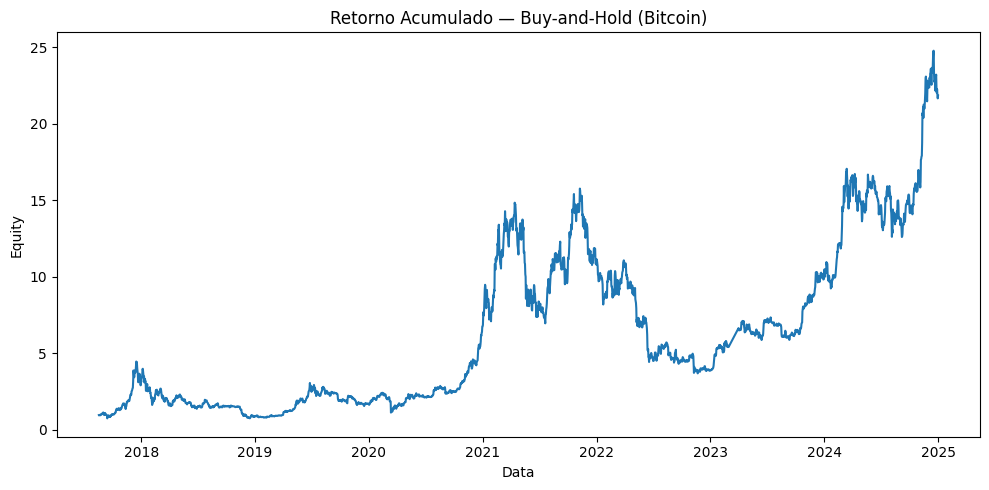

[OK] figura salva: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs\cap7\fig_7_01_cum_returns_buy_hold.png


In [26]:
# =========================================================
# CELL 4 — SEÇÃO 7.1: BUY-AND-HOLD (BENCHMARK)
# Outputs:
#   - tables/tab7/tab7_1_perf_buy_hold.tex
#   - figs/cap7/fig_7_01_cum_returns_buy_hold.png
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd

# 0) checagens mínimas
if "returns_btc" not in globals():
    raise NameError("returns_btc não está definido. Rode antes a CELL 2 (DADOS BASE).")

# 1) rodar buy-and-hold
bh_returns = run_buy_and_hold(returns_btc)

# 2) métricas
metrics_bh = performance_metrics(bh_returns, freq=365, rf=0.0)
display(metrics_bh.to_frame(name="Buy-and-Hold"))

# 3) export tabela (SAFE: tabular only + booktabs ok)
out_tab = TAB7_DIR / "tab7_1_perf_buy_hold.tex"

tab_df = metrics_bh.to_frame(name="Buy-and-Hold").copy()
tab_df.index.name = "Métrica"
tab_df.columns = ["Valor"]

tabular = tab_df.to_latex(
    index=True,
    escape=True,
    float_format="%.4f",
    column_format="lr",
    header=True
)

# garante que seja só tabular (sem table float)
tabular = tabular.replace("\\begin{table}", "%\\begin{table}")
tabular = tabular.replace("\\end{table}", "%\\end{table}")

out_tab.write_text(tabular, encoding="utf-8")
print("[OK] tabela salva:", out_tab)

# 4) figura (plot + save)
cum_bh = (1.0 + bh_returns).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(cum_bh)
plt.title("Retorno Acumulado — Buy-and-Hold (Bitcoin)")
plt.xlabel("Data")
plt.ylabel("Equity")
plt.tight_layout()
plt.show()

out_fig = CAP7_FIG_DIR / "fig_7_01_cum_returns_buy_hold.png"
plt.figure(figsize=(10, 5))
plt.plot(cum_bh)
plt.title("Retorno Acumulado — Buy-and-Hold (Bitcoin)")
plt.xlabel("Data")
plt.ylabel("Equity")
plt.tight_layout()
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.close()

print("[OK] figura salva:", out_fig)


In [11]:
# =========================================================
# CELL 7.1 — DADOS BASE (OBRIGATÓRIO)
# Cria:
#   - returns_btc (retornos diários BTC)
#   - bvrp (série BVRP 30d)
# Requer:
#   - PROJECT_ROOT definido (seu SETUP GLOBAL)
# =========================================================

import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------------------------
# 0) Checar PROJECT_ROOT / dirs
# -----------------------------------------
for name in ["PROJECT_ROOT", "CAP7_FIG_DIR", "TAB7_DIR"]:
    if name not in globals():
        raise NameError(f"{name} não está definido. Rode antes o SETUP GLOBAL — Capítulo 7.")

DATA_DIR = PROJECT_ROOT / "data"

# -----------------------------------------
# 1) GERAR returns_btc a partir do CSV de PREÇOS diários
#    (seu log mostra: data\btc_prices.csv.csv)
# -----------------------------------------
price_candidates = [
    DATA_DIR / "btc_prices.csv.csv",   # <- o seu (pelo log)
    DATA_DIR / "btc_prices.csv",
    DATA_DIR / "btc_spot_1d.csv",
    DATA_DIR / "BTCUSDT_1d.csv",
    DATA_DIR / "binance_btcusdt_1d.csv",
]

price_path = next((p for p in price_candidates if p.exists()), None)
if price_path is None:
    raise FileNotFoundError(
        "Não encontrei CSV de preços do BTC em data/. Tente um destes nomes:\n"
        + "\n".join([str(p.name) for p in price_candidates])
    )

dfp = pd.read_csv(price_path)

# inferir coluna de data
date_cols = [c for c in dfp.columns if c.lower() in ["date", "data", "dt", "timestamp", "time"]]
if not date_cols:
    # tenta primeira coluna como data
    date_cols = [dfp.columns[0]]
date_col = date_cols[0]

dfp[date_col] = pd.to_datetime(dfp[date_col], errors="coerce")
dfp = dfp.dropna(subset=[date_col]).sort_values(date_col).set_index(date_col)

# inferir coluna de preço (close)
close_candidates = ["close", "Close", "adj_close", "Adj Close", "price", "Price"]
close_col = next((c for c in close_candidates if c in dfp.columns), None)
if close_col is None:
    # tenta achar algo que contenha close
    maybe = [c for c in dfp.columns if "close" in c.lower()]
    if maybe:
        close_col = maybe[0]
    else:
        raise ValueError(f"Não achei coluna de fechamento no CSV. Colunas: {dfp.columns.tolist()}")

close = pd.to_numeric(dfp[close_col], errors="coerce").dropna()
returns_btc = close.pct_change().dropna()
returns_btc.name = "btc_returns"

print("[OK] returns_btc gerado a partir de:", price_path)
print("[OK] método: pct_change(close)")
print("[OK] returns_btc:", returns_btc.index.min().date(), "->", returns_btc.index.max().date(), "| N =", len(returns_btc))
display(returns_btc.head())

# -----------------------------------------
# 2) CARREGAR BVRP (VRP = BVRP) do dataset
# -----------------------------------------
bvrp_candidates = [
    DATA_DIR / "vrp_with_targets.csv",      # <- o seu (já confirmou antes)
    DATA_DIR / "bvrp_with_targets.csv",
    DATA_DIR / "vrp_30d_dataset.csv",
    DATA_DIR / "vrp_with_regimes.csv",
    DATA_DIR / "ml_dataset.csv",
    DATA_DIR / "dataset_bvrp_full.csv",
    DATA_DIR / "dataset_bvrp_with_skew.csv",
]

bvrp_path = next((p for p in bvrp_candidates if p.exists()), None)
if bvrp_path is None:
    raise FileNotFoundError(
        "Não encontrei dataset com BVRP em data/. Tente conferir estes nomes:\n"
        + "\n".join([str(p.name) for p in bvrp_candidates])
    )

df = pd.read_csv(bvrp_path)

# inferir coluna de data
date_cols = [c for c in df.columns if c.lower() in ["date", "data", "dt", "timestamp", "time"]]
if not date_cols:
    date_cols = [df.columns[0]]
dcol = date_cols[0]

df[dcol] = pd.to_datetime(df[dcol], errors="coerce")
df = df.dropna(subset=[dcol]).sort_values(dcol).set_index(dcol)

# inferir coluna VRP/BVRP
vrp_cols_priority = ["bvrp_30d", "vrp_30d", "bvrp", "vrp", "vrp30", "bvrp30"]
vrp_col = next((c for c in vrp_cols_priority if c in df.columns), None)
if vrp_col is None:
    vrp_like = [c for c in df.columns if "vrp" in c.lower()]
    if not vrp_like:
        raise ValueError(f"Não achei coluna VRP/BVRP no arquivo. Colunas: {df.columns.tolist()[:40]}")
    vrp_col = vrp_like[0]

bvrp = pd.to_numeric(df[vrp_col], errors="coerce").dropna()
bvrp.name = "bvrp_30d"

print("[OK] bvrp carregado de:", bvrp_path)
print("[OK] coluna usada:", vrp_col, "-> renomeada para bvrp_30d")
print("[OK] bvrp:", bvrp.index.min().date(), "->", bvrp.index.max().date(), "| N =", len(bvrp))
display(bvrp.head())

# (opcional) checar interseção
common_index = returns_btc.index.intersection(bvrp.index)
print("[OK] interseção returns x bvrp:", common_index.min().date(), "->", common_index.max().date(), "| N =", len(common_index))


[OK] returns_btc gerado a partir de: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\data\btc_prices.csv.csv
[OK] método: pct_change(close)
[OK] returns_btc: 2017-08-18 -> 2024-12-31 | N = 2662


date
2017-08-18   -0.041238
2017-08-19    0.007694
2017-08-20   -0.012969
2017-08-21   -0.017201
2017-08-22    0.005976
Name: btc_returns, dtype: float64

[OK] bvrp carregado de: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\data\vrp_with_targets.csv
[OK] coluna usada: vrp_30d -> renomeada para bvrp_30d
[OK] bvrp: 2023-02-27 -> 2024-12-11 | N = 623


date
2023-02-27    -1.740368
2023-02-28    -0.922610
2023-04-01   -29.054138
2023-04-02   -27.123177
2023-04-03   -25.550827
Name: bvrp_30d, dtype: float64

[OK] interseção returns x bvrp: 2023-02-27 -> 2024-12-11 | N = 623


,BVRP Quantil 80%
Annual Return,0.055501
Annual Volatility,0.117962
Sharpe Ratio,0.470496
Max Drawdown,-0.171102


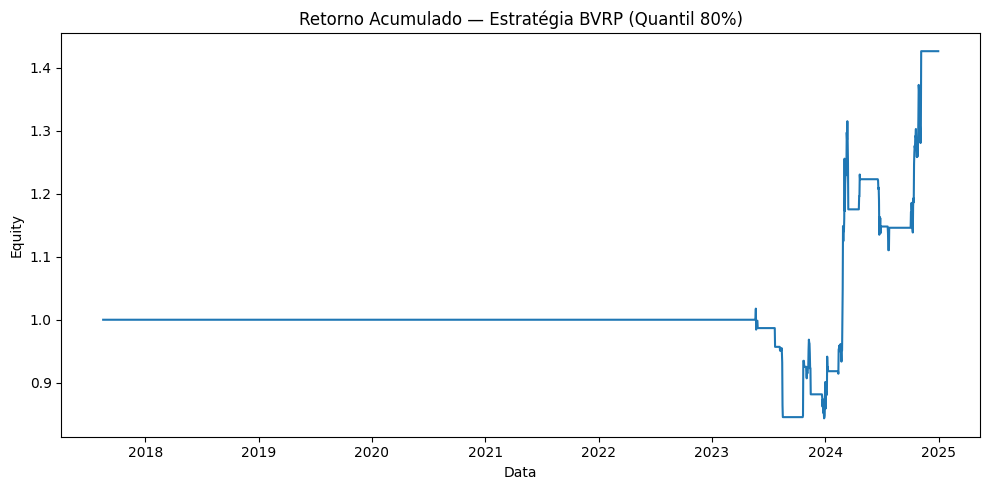

[OK] tabela salva: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\tables\tab7\tab7_2_perf_bvrp_quantile.tex
[OK] figura salva: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs\cap7\fig_7_02_cum_returns_bvrp_quantile.png


In [13]:
# =========================================================
# CELL 7.2 — ESTRATÉGIA CONDICIONAL AO BVRP (QUANTIL SUPERIOR)
# Outputs:
#   - tables/tab7/tab7_2_perf_bvrp_quantile.tex
#   - figs/cap7/fig_7_02_cum_returns_bvrp_quantile.png
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.cap7.strategy_vrp_quantile import run_bvrp_strategy
from scripts.cap7.strategy_buy_hold import performance_metrics

# -----------------------------------------
# 0) checagens mínimas
# -----------------------------------------
for name in ["returns_btc", "bvrp", "TAB7_DIR", "CAP7_FIG_DIR"]:
    if name not in globals():
        raise NameError(f"{name} não está definido. Rode o SETUP GLOBAL do Cap. 7 e as células anteriores.")

# alinhar BVRP nas datas do retorno (garantia)
bvrp_aligned = bvrp.reindex(returns_btc.index).ffill()

q = 0.80

# estratégia (retornos + posição 0/1), com lag=1 para evitar look-ahead
bvrp_returns, bvrp_pos = run_bvrp_strategy(returns_btc, bvrp_aligned, q=q, lag=1)

# métricas
metrics_bvrp = performance_metrics(bvrp_returns, freq=365)
display(metrics_bvrp.to_frame(name=f"BVRP Quantil {int(q*100)}%"))

# curva acumulada
cum_bvrp = (1 + bvrp_returns.fillna(0.0)).cumprod()

# --- FIGURA (preview + save)
plt.figure(figsize=(10,5))
plt.plot(cum_bvrp)
plt.title(f"Retorno Acumulado — Estratégia BVRP (Quantil {int(q*100)}%)")
plt.xlabel("Data")
plt.ylabel("Equity")
plt.tight_layout()
plt.show()

# -----------------------------------------
# EXPORTS (LaTeX tabular-only + figura)
# -----------------------------------------
out_table = TAB7_DIR / "tab7_2_perf_bvrp_quantile.tex"
metrics_bvrp.to_frame(name=f"BVRP Quantil {int(q*100)}%").to_latex(
    out_table,
    float_format="%.4f",
    header=True,
    index=True
)
print("[OK] tabela salva:", out_table)

out_fig = CAP7_FIG_DIR / "fig_7_02_cum_returns_bvrp_quantile.png"
plt.figure(figsize=(10,5))
plt.plot(cum_bvrp)
plt.title(f"Retorno Acumulado — Estratégia BVRP (Quantil {int(q*100)}%)")
plt.xlabel("Data")
plt.ylabel("Equity")
plt.tight_layout()
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.close()
print("[OK] figura salva:", out_fig)


[OK] Período comum: 2023-02-27 -> 2024-12-11 | N = 623


,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Turnover,% Time Invested
q60,0.478706,0.299551,1.598077,-0.208543,0.070740,0.398074
q70,0.313229,0.282506,1.108748,-0.221122,0.077170,0.298555
q80,0.261996,0.242396,1.080856,-0.150478,0.057878,0.200642
q90,0.298024,0.186618,1.596973,-0.102955,0.038585,0.101124


[OK] tabela salva: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\tables\tab7\tab7_3_perf_bvrp_multi_quantile.tex


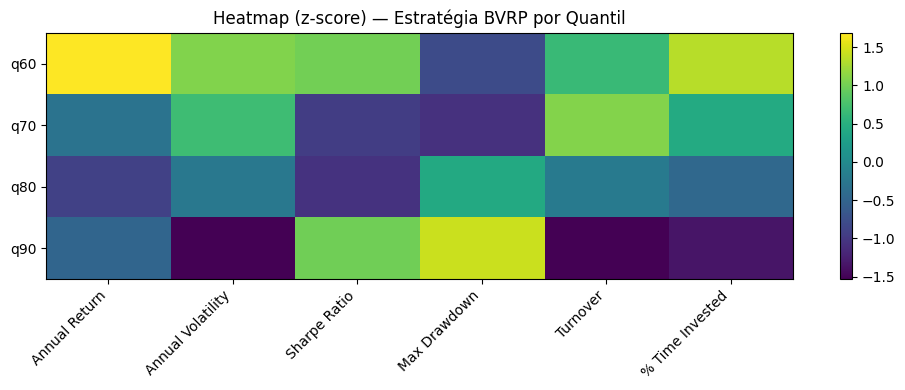

[OK] figura salva: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs\cap7\fig_7_03_heatmap_bvrp_quantile_metrics.png
[OK] Seção 7.3 concluída: tabela + heatmap gerados e salvos.


In [14]:
# =========================================================
# CELL 7.3 — ROBUSTEZ POR QUANTIS DO BVRP (a + b + c)
# Outputs:
#   - tables/tab7/tab7_3_perf_bvrp_multi_quantile.tex
#   - figs/cap7/fig_7_03_heatmap_bvrp_quantile_metrics.png
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scripts.cap7.strategy_vrp_quantile import run_bvrp_strategy

# -----------------------------------------
# 0) checagens mínimas
# -----------------------------------------
for name in ["returns_btc", "bvrp", "TAB7_DIR", "CAP7_FIG_DIR"]:
    if name not in globals():
        raise NameError(f"{name} não está definido. Rode o SETUP GLOBAL do Cap. 7 e as células anteriores.")

# alinhar séries (interseção)
common_index = returns_btc.index.intersection(bvrp.index)
ret = returns_btc.loc[common_index].astype(float)
bvrp_aligned = bvrp.loc[common_index].astype(float)

print("[OK] Período comum:", common_index.min().date(), "->", common_index.max().date(), "| N =", len(common_index))

# -----------------------------------------
# 1) funções auxiliares (turnover e % investido)
# -----------------------------------------
def compute_turnover(position: pd.Series) -> float:
    pos = position.fillna(0.0).astype(float)
    return float(pos.diff().abs().mean())

def compute_invested_pct(position: pd.Series) -> float:
    pos = position.fillna(0.0).astype(float)
    return float((pos > 0).mean())

def perf_metrics_extended(returns: pd.Series, position: pd.Series, freq: int = 365) -> pd.Series:
    r = returns.dropna().astype(float)
    if len(r) == 0:
        return pd.Series({
            "Annual Return": np.nan,
            "Annual Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown": np.nan,
            "Turnover": np.nan,
            "% Time Invested": np.nan
        })

    ann_ret = r.mean() * freq
    ann_vol = r.std(ddof=1) * np.sqrt(freq)
    sharpe = np.nan if (ann_vol == 0 or np.isnan(ann_vol)) else (ann_ret / ann_vol)

    equity = (1.0 + r).cumprod()
    dd = equity / equity.cummax() - 1.0
    max_dd = dd.min()

    pos_aligned = position.reindex(r.index).fillna(0.0)

    return pd.Series({
        "Annual Return": ann_ret,
        "Annual Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "Turnover": compute_turnover(pos_aligned),
        "% Time Invested": compute_invested_pct(pos_aligned)
    })

# -----------------------------------------
# 2) rodar estratégia para múltiplos quantis
# -----------------------------------------
quantiles = [0.60, 0.70, 0.80, 0.90]
rows = {}

for q in quantiles:
    strat_ret, pos = run_bvrp_strategy(ret, bvrp_aligned, q=q, lag=1)
    rows[f"q{int(q*100)}"] = perf_metrics_extended(strat_ret, pos, freq=365)

perf_table = pd.DataFrame(rows).T
display(perf_table)

# -----------------------------------------
# 3) EXPORT TABELA 7.3 (tabular-only, robusto no Overleaf)
# -----------------------------------------
out_tab = TAB7_DIR / "tab7_3_perf_bvrp_multi_quantile.tex"

perf_table_export = perf_table.copy()

# arredonda (sem applymap pra evitar warning)
for c in perf_table_export.columns:
    perf_table_export[c] = perf_table_export[c].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "")

tabular = perf_table_export.to_latex(
    index=True,
    escape=True,
    header=True,
    index_names=True,
    caption=False,
    label=False,
    column_format="l" + "r"*perf_table_export.shape[1],
    bold_rows=False
)

Path(out_tab).write_text(tabular, encoding="utf-8")
print("[OK] tabela salva:", out_tab)

# -----------------------------------------
# 4) HEATMAP (z-score por métrica) + export figura
# -----------------------------------------
heat = perf_table.copy()
heat_z = (heat - heat.mean(axis=0)) / heat.std(axis=0, ddof=0)

plt.figure(figsize=(10, 4))
plt.imshow(heat_z.values, aspect="auto")
plt.xticks(range(len(heat_z.columns)), heat_z.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_z.index)), heat_z.index)
plt.colorbar()
plt.title("Heatmap (z-score) — Estratégia BVRP por Quantil")
plt.tight_layout()
plt.show()

out_fig = CAP7_FIG_DIR / "fig_7_03_heatmap_bvrp_quantile_metrics.png"
plt.figure(figsize=(10, 4))
plt.imshow(heat_z.values, aspect="auto")
plt.xticks(range(len(heat_z.columns)), heat_z.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_z.index)), heat_z.index)
plt.colorbar()
plt.title("Heatmap (z-score) — Estratégia BVRP por Quantil")
plt.tight_layout()
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.close()
print("[OK] figura salva:", out_fig)

print("[OK] Seção 7.3 concluída: tabela + heatmap gerados e salvos.")


[OK] returns_btc: 2017-08-18 -> 2024-12-31 | N = 2662
[OK] bvrp: 2023-02-27 -> 2024-12-11 | N = 623
[OK] rv: 2023-02-27 -> 2024-12-11 | N = 623
[OK] interseção: 2023-02-27 -> 2024-12-11 | N = 623


,ret,bvrp,rv
date,,,
2023-02-27,-0.002664,-1.740368,52.180368
2023-02-28,-0.014921,-0.922610,51.292610
2023-04-01,0.229507,-29.054138,87.224138
2023-04-02,-0.009871,-27.123177,87.403177
2023-04-03,-0.013200,-25.550827,87.380827


[OK] cortes RV tercis: 40.98969336342262 50.92570159129034


,dias
Alto,208
Baixo,208
Médio,207


[CHECK] dias investido (pos_all>0): 125 de 623

[OK] Tabela de desempenho por regime:


,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Turnover,% Time Invested
Regime,,,,,,
Baixo,0.041311,0.135890,0.303999,-0.143351,0.028939,0.112360
Médio,0.228163,0.178165,1.280624,-0.124948,0.038585,0.067416
Alto,-0.007478,0.092669,-0.080696,-0.106357,0.009646,0.020867


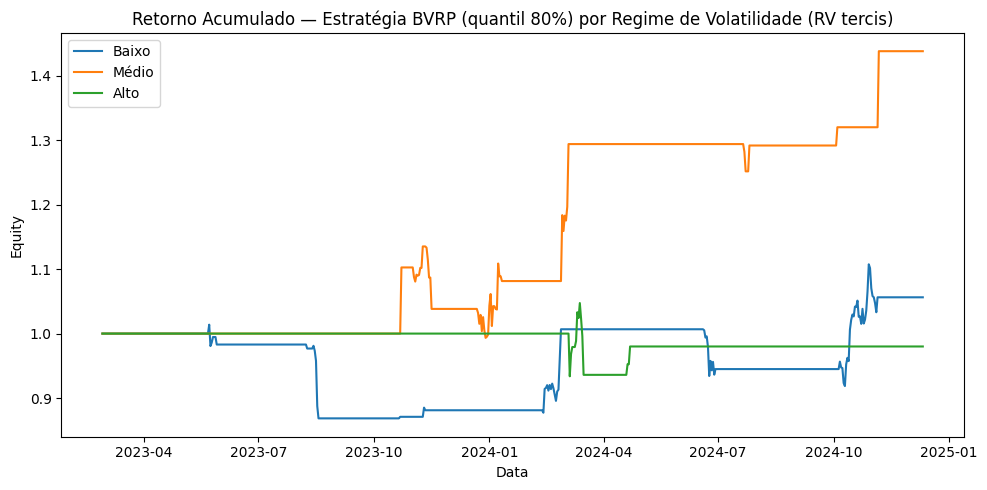

[OK] figura salva: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs\cap7\fig_7_04_cum_returns_bvrp_by_regime.png
[OK] tabela salva: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\tables\tab7\tab7_4_perf_bvrp_regimes.tex


C:\Users\EM2024006937\AppData\Local\Temp\ipykernel_32260\1405313777.py:180: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tab_exp = tab_exp.applymap(lambda x: f"{x:.4f}" if pd.notnull(x) else "")


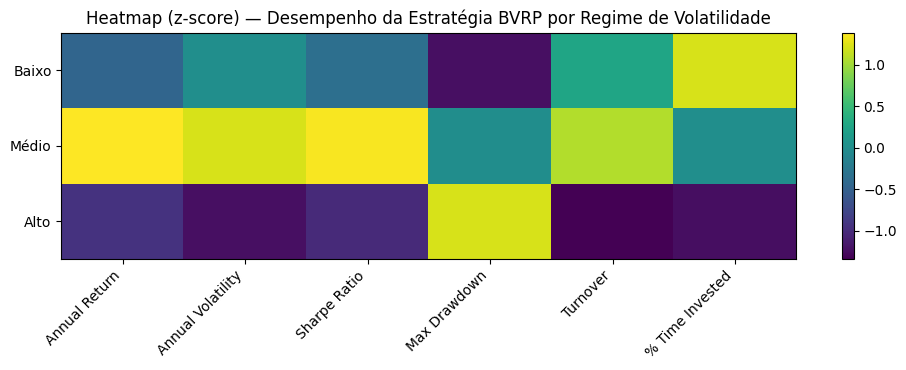

[OK] figura salva: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs\cap7\fig_7_05_heatmap_bvrp_regimes.png

[OK] Seção 7.4 pronta: tabela + 2 figuras geradas e salvas.


In [17]:
# =========================================================
# CELL 7.4 — BVRP + REGIMES DE VOLATILIDADE (RV_30D)
# Requer (já criados em cells anteriores):
#   - PROJECT_ROOT, CAP7_FIG_DIR, TAB7_DIR (SETUP GLOBAL)
#   - returns_btc e bvrp (CELL 7.1 — DADOS BASE)
# Outputs:
#   - tables/tab7/tab7_4_perf_bvrp_regimes.tex
#   - figs/cap7/fig_7_04_cum_returns_bvrp_by_regime.png
#   - figs/cap7/fig_7_05_heatmap_bvrp_regimes.png
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.cap7.strategy_vrp_quantile import run_bvrp_strategy  # (ret, pos) com lag

# ---------------------------------------------------------
# 0) Checagens mínimas
# ---------------------------------------------------------
for name in ["PROJECT_ROOT", "CAP7_FIG_DIR", "TAB7_DIR", "returns_btc", "bvrp"]:
    if name not in globals():
        raise NameError(f"{name} não está definido. Rode antes: SETUP GLOBAL + CELL 7.1 (DADOS BASE).")

# ---------------------------------------------------------
# 1) Carregar RV_30D do vrp_with_targets.csv (fonte padrão)
# ---------------------------------------------------------
path = PROJECT_ROOT / "data" / "vrp_with_targets.csv"
if not path.exists():
    raise FileNotFoundError(f"Não encontrei: {path}. (RV_30D precisa estar nesse arquivo.)")

df_rv = pd.read_csv(path)

# inferir coluna de data
date_cols = [c for c in df_rv.columns if c.lower() in ["date", "data", "dt", "timestamp", "time"]]
if not date_cols:
    date_cols = [df_rv.columns[0]]
dcol = date_cols[0]

df_rv[dcol] = pd.to_datetime(df_rv[dcol], errors="coerce")
df_rv = df_rv.dropna(subset=[dcol]).sort_values(dcol).set_index(dcol)

if "rv_30d" not in df_rv.columns:
    raise ValueError("Não encontrei coluna rv_30d em vrp_with_targets.csv")

rv = pd.to_numeric(df_rv["rv_30d"], errors="coerce").dropna()
rv.name = "rv_30d"

print("[OK] returns_btc:", returns_btc.index.min().date(), "->", returns_btc.index.max().date(), "| N =", len(returns_btc))
print("[OK] bvrp:", bvrp.index.min().date(), "->", bvrp.index.max().date(), "| N =", len(bvrp))
print("[OK] rv:", rv.index.min().date(), "->", rv.index.max().date(), "| N =", len(rv))

# ---------------------------------------------------------
# 2) Alinhar séries (interseção)
# ---------------------------------------------------------
common_index = returns_btc.index.intersection(bvrp.index).intersection(rv.index)

returns_aligned = returns_btc.loc[common_index].astype(float)
bvrp_aligned = bvrp.loc[common_index].astype(float)
rv_aligned = rv.loc[common_index].astype(float)

print("[OK] interseção:", common_index.min().date(), "->", common_index.max().date(), "| N =", len(common_index))
display(pd.DataFrame({"ret": returns_aligned, "bvrp": bvrp_aligned, "rv": rv_aligned}).head())

# ---------------------------------------------------------
# 3) Definir regimes (tercis de RV)
# ---------------------------------------------------------
q1, q2 = rv_aligned.quantile([1/3, 2/3])

regime = pd.Series(index=common_index, dtype="object")
regime[rv_aligned <= q1] = "Baixo"
regime[(rv_aligned > q1) & (rv_aligned <= q2)] = "Médio"
regime[rv_aligned > q2] = "Alto"

print("[OK] cortes RV tercis:", float(q1), float(q2))
display(regime.value_counts().to_frame("dias"))

# ---------------------------------------------------------
# 4) Estratégia base pelo quantil do BVRP (com lag=1 via função)
#    Depois “filtra” por regime: pos_reg = pos_all * 1{regime==X}
# ---------------------------------------------------------
q = 0.80
strat_all, pos_all = run_bvrp_strategy(returns_aligned, bvrp_aligned, q=q, lag=1)

print("[CHECK] dias investido (pos_all>0):", int((pos_all > 0).sum()), "de", len(pos_all))

# ---------------------------------------------------------
# 5) Métricas estendidas (inclui turnover e % investido)
# ---------------------------------------------------------
def compute_turnover(position: pd.Series) -> float:
    pos = position.fillna(0.0).astype(float)
    return float(pos.diff().abs().mean())

def compute_invested_pct(position: pd.Series) -> float:
    pos = position.fillna(0.0).astype(float)
    return float((pos > 0).mean())

def perf_metrics_extended(returns: pd.Series, position: pd.Series, freq: int = 365) -> pd.Series:
    r = returns.dropna().astype(float)
    if len(r) == 0:
        return pd.Series({
            "Annual Return": np.nan,
            "Annual Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown": np.nan,
            "Turnover": np.nan,
            "% Time Invested": np.nan,
        })

    ann_ret = r.mean() * freq
    ann_vol = r.std(ddof=1) * np.sqrt(freq)
    sharpe = np.nan if ann_vol == 0 or np.isnan(ann_vol) else ann_ret / ann_vol

    equity = (1.0 + r).cumprod()
    dd = equity / equity.cummax() - 1.0
    max_dd = float(dd.min())

    turnover = compute_turnover(position.loc[r.index])
    invested = compute_invested_pct(position.loc[r.index])

    return pd.Series({
        "Annual Return": float(ann_ret),
        "Annual Volatility": float(ann_vol),
        "Sharpe Ratio": float(sharpe) if sharpe == sharpe else np.nan,
        "Max Drawdown": float(max_dd),
        "Turnover": float(turnover),
        "% Time Invested": float(invested),
    })

regimes = ["Baixo", "Médio", "Alto"]
rows = {}
equity_curves = {}

for reg in regimes:
    mask = (regime == reg).astype(float)
    pos_reg = (pos_all * mask).reindex(common_index).fillna(0.0)
    strat_reg = pos_reg * returns_aligned
    rows[reg] = perf_metrics_extended(strat_reg, pos_reg, freq=365)
    equity_curves[reg] = (1.0 + strat_reg).cumprod()

perf_table = pd.DataFrame(rows).T
perf_table.index.name = "Regime"

print("\n[OK] Tabela de desempenho por regime:")
display(perf_table)

# ---------------------------------------------------------
# 6) FIG 7.4.1 — curvas acumuladas por regime
# ---------------------------------------------------------
plt.figure(figsize=(10,5))
for reg in regimes:
    plt.plot(equity_curves[reg], label=reg)
plt.title(f"Retorno Acumulado — Estratégia BVRP (quantil {int(q*100)}%) por Regime de Volatilidade (RV tercis)")
plt.xlabel("Data")
plt.ylabel("Equity")
plt.legend()
plt.tight_layout()
plt.show()

out_fig1 = CAP7_FIG_DIR / "fig_7_04_cum_returns_bvrp_by_regime.png"
plt.figure(figsize=(10,5))
for reg in regimes:
    plt.plot(equity_curves[reg], label=reg)
plt.title(f"Retorno Acumulado — Estratégia BVRP (quantil {int(q*100)}%) por Regime de Volatilidade (RV tercis)")
plt.xlabel("Data")
plt.ylabel("Equity")
plt.legend()
plt.tight_layout()
plt.savefig(out_fig1, dpi=300, bbox_inches="tight")
plt.close()
print("[OK] figura salva:", out_fig1)

# ---------------------------------------------------------
# 7) EXPORT TABELA 7.4 — TABULAR ONLY (robusto no Overleaf)
#    (não mexer em \toprule manualmente!)
# ---------------------------------------------------------
out_tab = TAB7_DIR / "tab7_4_perf_bvrp_regimes.tex"

tab_exp = perf_table.copy()
tab_exp = tab_exp.applymap(lambda x: f"{x:.4f}" if pd.notnull(x) else "")

latex = tab_exp.to_latex(
    index=True,
    escape=True,
    header=True,
    column_format="l" + "r"*tab_exp.shape[1]
)


Path(out_tab).write_text(latex, encoding="utf-8")
print("[OK] tabela salva:", out_tab)

# ---------------------------------------------------------
# 8) FIG 7.4.2 — heatmap z-score por regime
# ---------------------------------------------------------
heat_z = (perf_table - perf_table.mean(axis=0)) / perf_table.std(axis=0, ddof=0)

plt.figure(figsize=(10,3.8))
plt.imshow(heat_z.values, aspect="auto")
plt.xticks(range(len(heat_z.columns)), heat_z.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_z.index)), heat_z.index)
plt.title("Heatmap (z-score) — Desempenho da Estratégia BVRP por Regime de Volatilidade")
plt.colorbar()
plt.tight_layout()
plt.show()

out_fig2 = CAP7_FIG_DIR / "fig_7_05_heatmap_bvrp_regimes.png"
plt.figure(figsize=(10,3.8))
plt.imshow(heat_z.values, aspect="auto")
plt.xticks(range(len(heat_z.columns)), heat_z.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_z.index)), heat_z.index)
plt.title("Heatmap (z-score) — Desempenho da Estratégia BVRP por Regime de Volatilidade")
plt.colorbar()
plt.tight_layout()
plt.savefig(out_fig2, dpi=300, bbox_inches="tight")
plt.close()
print("[OK] figura salva:", out_fig2)

print("\n[OK] Seção 7.4 pronta: tabela + 2 figuras geradas e salvas.")


XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX